In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
from dynamicTasteDistortion.simulationConstants import (
    RESULTS_PATH,
)

In [5]:
data_type = "ml"
file_size = "1m"
preffix = "exp=default_experiment"
num_users="1000"
rounds = "500"
num_rounds_per_eval = 5

In [6]:
def get_metrics(data_type, file_size, num_users, rounds, preffix, num_rounds_per_eval):
    if preffix is None:
        base_artifacts_path = (
        Path(RESULTS_PATH)
            / f"{data_type}_{file_size}"
            / "simulated"
            / f"rounds={rounds}"
            / f"users={num_users}"
            / f"eval_every={num_rounds_per_eval}"
        )
    else:
        base_artifacts_path = (
            Path(RESULTS_PATH)
            / f"{data_type}_{file_size}"
            / "simulated"
            / preffix
            / f"rounds={rounds}"
            / f"users={num_users}"
            / f"eval_every={num_rounds_per_eval}"
        )
    # Read maces pickle file
    file_name = base_artifacts_path / "maces.pkl"
    maces = pd.read_pickle(file_name)

    # Read maces pickle file
    file_name = base_artifacts_path / "kl_divs.pkl"
    kl_divs = pd.read_pickle(file_name)

    return maces, kl_divs

## Movielens 1m

In [7]:
maces, kl_divs = get_metrics(
    data_type, file_size, num_users, rounds, preffix, num_rounds_per_eval
)

In [8]:
maces_random, kl_divs_random = get_metrics(
    data_type, file_size, num_users, rounds, "exp=ablation_random_rec", num_rounds_per_eval
)

In [9]:
maces_ma = pd.Series(maces).rolling(window=10).mean()
kl_divs_ma = pd.Series(kl_divs).rolling(window=10).mean()

maces_random_ma = pd.Series(maces_random).rolling(window=10).mean()
kl_divs_random_ma = pd.Series(kl_divs_random).rolling(window=10).mean()

### With oracle matrix as feedback simulator

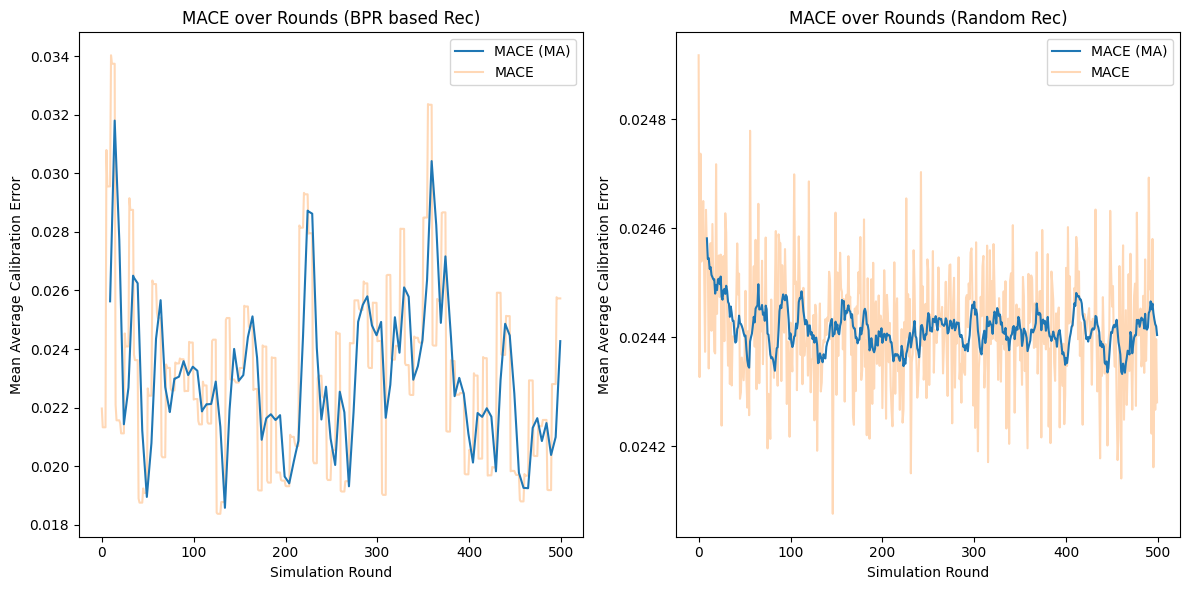

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Define the retraining rounds (0, 5, 10... up to the length of your data)
# Assuming maces and maces_random have the same length
retrain_rounds = range(0, len(maces), 5)

# --- First Plot: BPR ---
plt.subplot(1, 2, 1)
plt.plot(maces_ma, label="MACE (MA)", zorder=3)
plt.plot(maces, alpha=0.3, label="MACE", zorder=2)

# # Add vertical lines
# for i, round_idx in enumerate(retrain_rounds):
#     # We only add a label to the first line to avoid duplicating it in the legend
#     label = "Model Retrain" if i == 0 else ""
#     plt.axvline(x=round_idx, color='gray', linestyle='--', alpha=0.5, linewidth=1, label=label, zorder=1)

plt.title("MACE over Rounds (BPR based Rec)")
plt.xlabel("Simulation Round")
plt.ylabel("Mean Average Calibration Error")
plt.legend()

# --- Second Plot: Random ---
plt.subplot(1, 2, 2)
plt.plot(maces_random_ma, label="MACE (MA)", zorder=3)
plt.plot(maces_random, alpha=0.3, label="MACE", zorder=2)


plt.title("MACE over Rounds (Random Rec)")
plt.xlabel("Simulation Round")
plt.ylabel("Mean Average Calibration Error")
plt.legend()

plt.tight_layout()
plt.show()

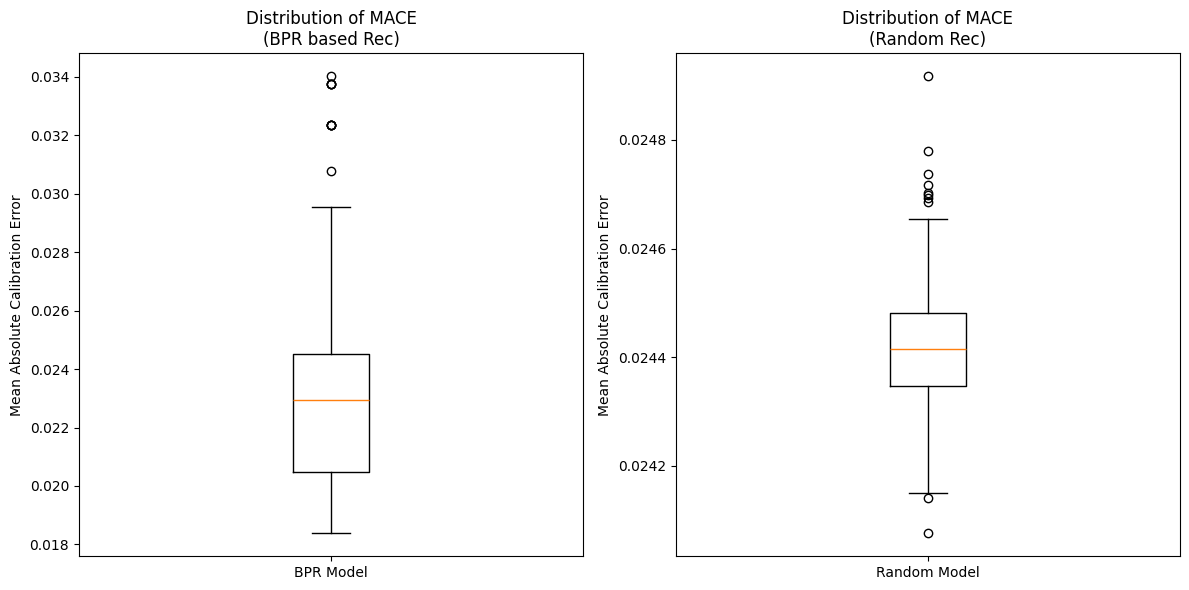

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# --- First Plot: MACE Distribution (BPR) ---
plt.subplot(1, 2, 1)
plt.boxplot(maces)
plt.title("Distribution of MACE\n(BPR based Rec)")
plt.ylabel("Mean Absolute Calibration Error")
plt.xticks([1], ["BPR Model"])

# --- Second Plot: MACE Distribution (Random) ---
plt.subplot(1, 2, 2)
plt.boxplot(maces_random)
plt.title("Distribution of MACE\n(Random Rec)")
plt.ylabel("Mean Absolute Calibration Error")
plt.xticks([1], ["Random Model"])

plt.tight_layout()
plt.show()

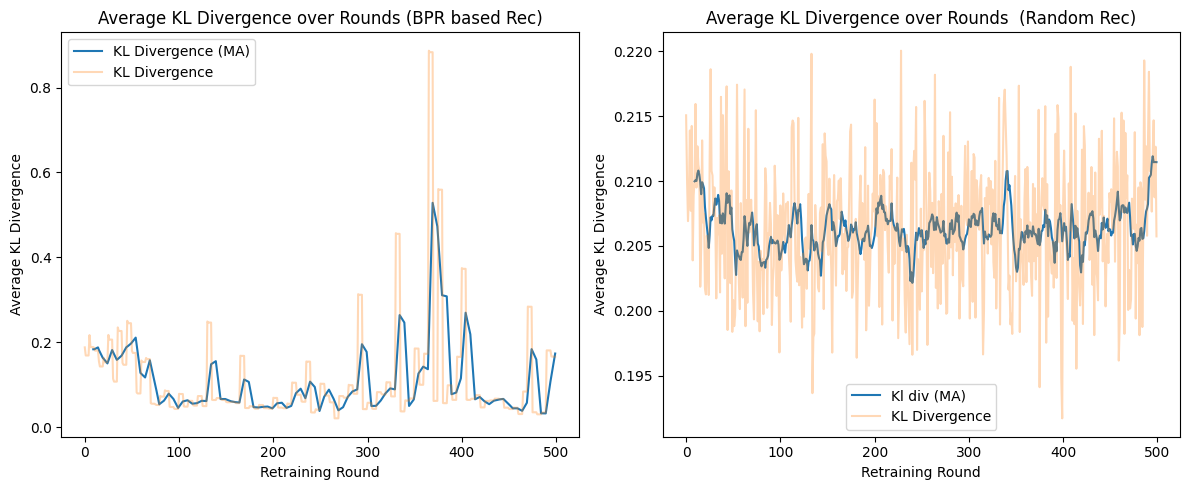

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # (rows, columns, index)
plt.plot(kl_divs_ma, label="KL Divergence (MA)")
plt.plot(kl_divs, alpha=0.3, label="KL Divergence")
plt.title("Average KL Divergence over Rounds (BPR based Rec)")
plt.xlabel("Retraining Round")
plt.ylabel("Average KL Divergence")
plt.legend()

plt.subplot(1, 2, 2) # Switch to the second slot
plt.plot(kl_divs_random_ma, label="Kl div (MA)")
plt.plot(kl_divs_random, alpha=0.3, label="KL Divergence")
plt.title("Average KL Divergence over Rounds  (Random Rec)")
plt.xlabel("Retraining Round")
plt.ylabel("Average KL Divergence")
plt.legend()

plt.tight_layout() # Prevents labels from overlapping
plt.show()

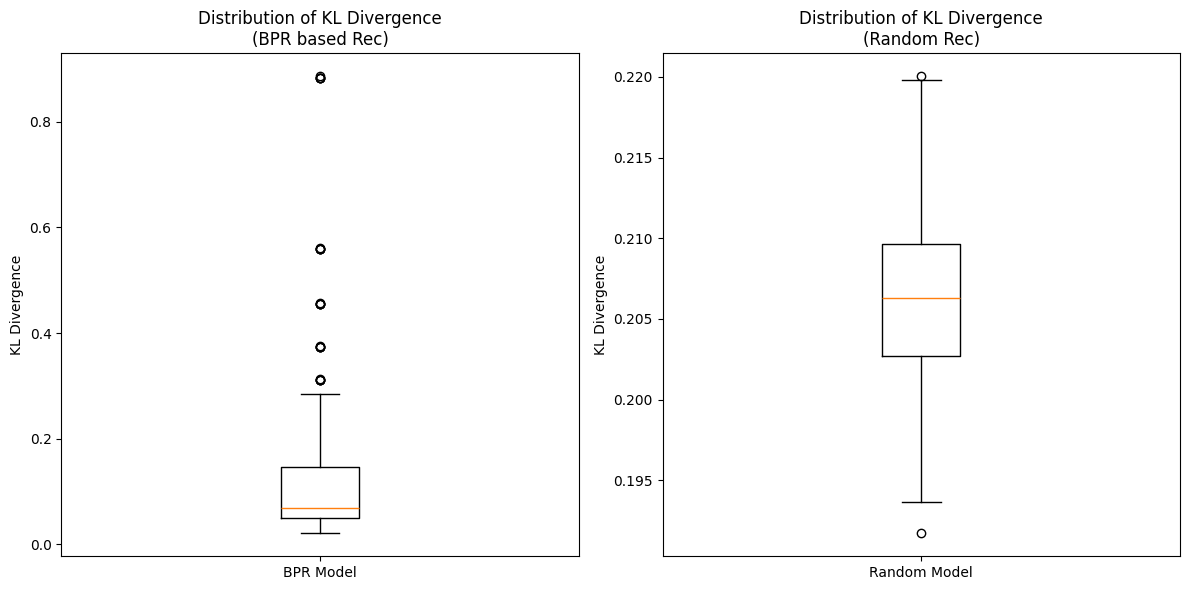

In [13]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# --- First Plot: KL Divergence (BPR) ---
plt.subplot(1, 2, 1)
plt.boxplot(kl_divs)
plt.title("Distribution of KL Divergence\n(BPR based Rec)")
plt.ylabel("KL Divergence")
# Usually, we remove the X-axis tick or label it as the model name for a single box
plt.xticks([1], ["BPR Model"]) 

# --- Second Plot: KL Divergence (Random) ---
plt.subplot(1, 2, 2)
plt.boxplot(kl_divs_random)
plt.title("Distribution of KL Divergence\n(Random Rec)")
plt.ylabel("KL Divergence")
plt.xticks([1], ["Random Model"])

plt.tight_layout()
plt.show()

### Without oracle matrix

In [14]:
data_type = "ml"
file_size = "1m"
preffix = "exp=random_rec_no_oracle_matrix_with_click_position_bias"
num_users="1000"
rounds = "500"
num_rounds_per_eval = 5

In [17]:
maces_random, kl_divs_random = get_metrics(
    data_type, file_size, num_users, rounds, preffix, num_rounds_per_eval
)

In [18]:
maces_ma_random = pd.Series(maces_random).rolling(window=10).mean()
kl_divs_ma_random = pd.Series(kl_divs_random).rolling(window=10).mean()

In [19]:
preffix = "exp=bpr_rec_no_oracle_matrix_with_click_position_bias"

maces, kl_divs = get_metrics(
    data_type, file_size, num_users, rounds, preffix, num_rounds_per_eval
)

In [20]:
maces_ma = pd.Series(maces).rolling(window=10).mean()
kl_divs_ma = pd.Series(kl_divs).rolling(window=10).mean()

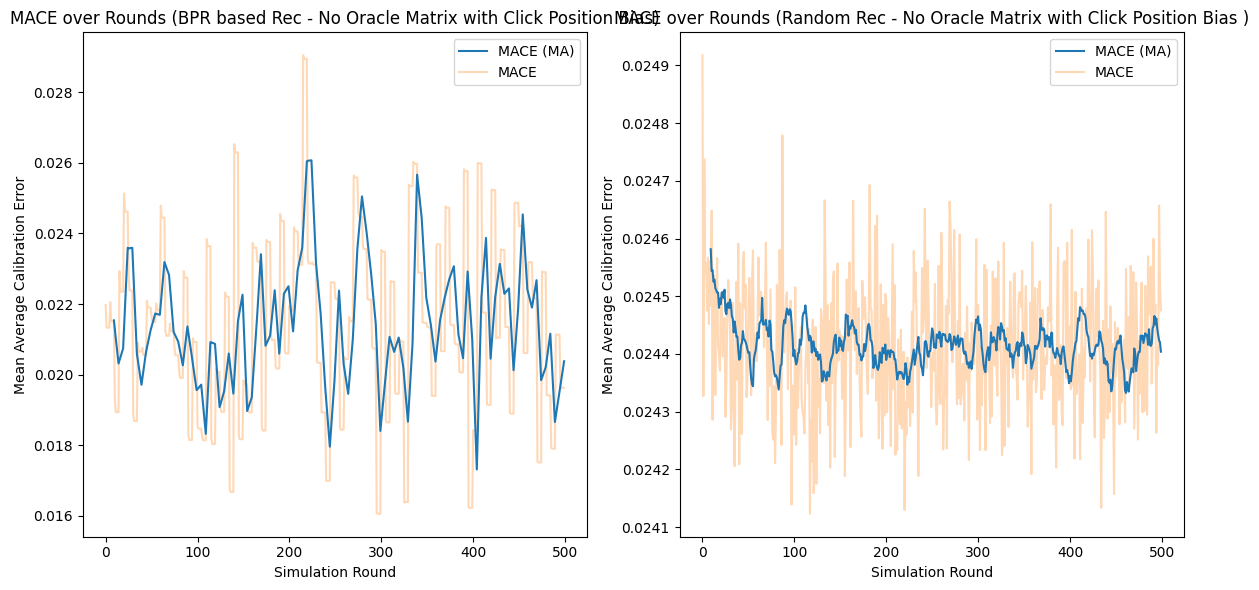

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Define the retraining rounds (0, 5, 10... up to the length of your data)
# Assuming maces and maces_random have the same length
retrain_rounds = range(0, len(maces), 5)

# --- First Plot: BPR ---
plt.subplot(1, 2, 1)
plt.plot(maces_ma, label="MACE (MA)", zorder=3)
plt.plot(maces, alpha=0.3, label="MACE", zorder=2)

# # Add vertical lines
# for i, round_idx in enumerate(retrain_rounds):
#     # We only add a label to the first line to avoid duplicating it in the legend
#     label = "Model Retrain" if i == 0 else ""
#     plt.axvline(x=round_idx, color='gray', linestyle='--', alpha=0.5, linewidth=1, label=label, zorder=1)

plt.title("MACE over Rounds (BPR based Rec - No Oracle Matrix with Click Position Bias)")
plt.xlabel("Simulation Round")
plt.ylabel("Mean Average Calibration Error")
plt.legend()

# --- Second Plot: Random ---
plt.subplot(1, 2, 2)
plt.plot(maces_random_ma, label="MACE (MA)", zorder=3)
plt.plot(maces_random, alpha=0.3, label="MACE", zorder=2)


plt.title("MACE over Rounds (Random Rec - No Oracle Matrix with Click Position Bias )")
plt.xlabel("Simulation Round")
plt.ylabel("Mean Average Calibration Error")
plt.legend()

plt.tight_layout()
plt.show()

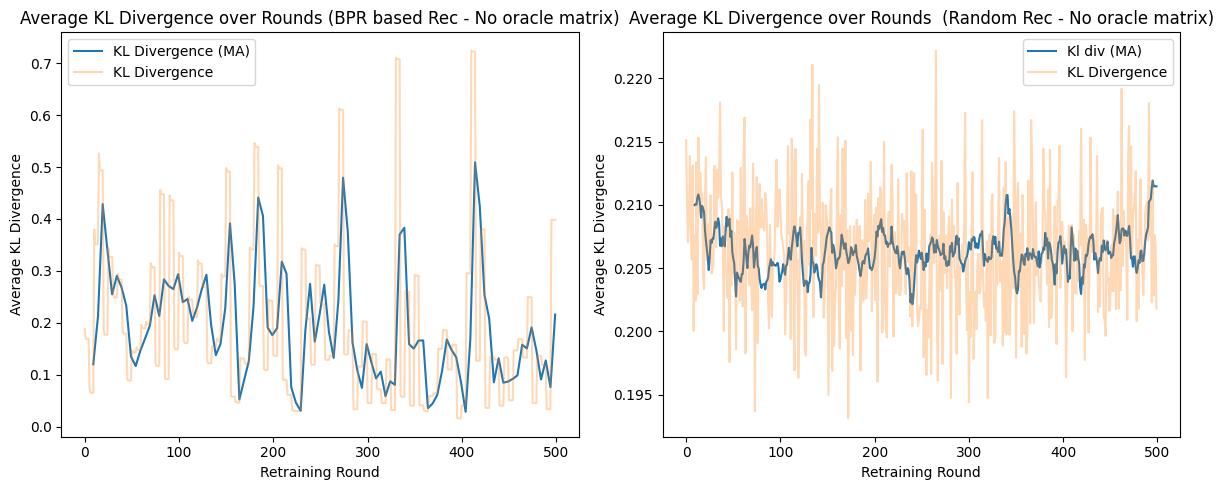

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # (rows, columns, index)
plt.plot(kl_divs_ma, label="KL Divergence (MA)")
plt.plot(kl_divs, alpha=0.3, label="KL Divergence")
plt.title("Average KL Divergence over Rounds (BPR based Rec - No oracle matrix)")
plt.xlabel("Retraining Round")
plt.ylabel("Average KL Divergence")
plt.legend()

plt.subplot(1, 2, 2) # Switch to the second slot
plt.plot(kl_divs_random_ma, label="Kl div (MA)")
plt.plot(kl_divs_random, alpha=0.3, label="KL Divergence")
plt.title("Average KL Divergence over Rounds  (Random Rec - No oracle matrix)")
plt.xlabel("Retraining Round")
plt.ylabel("Average KL Divergence")
plt.legend()

plt.tight_layout() # Prevents labels from overlapping
plt.show()

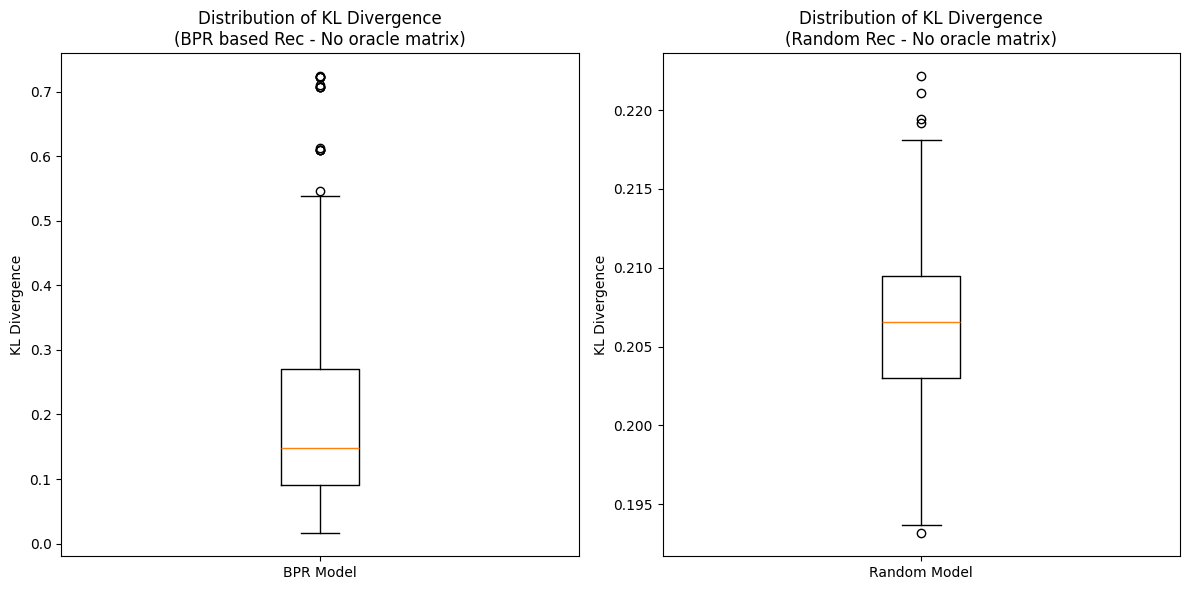

In [23]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# --- First Plot: KL Divergence (BPR) ---
plt.subplot(1, 2, 1)
plt.boxplot(kl_divs)
plt.title("Distribution of KL Divergence\n(BPR based Rec - No oracle matrix)")
plt.ylabel("KL Divergence")
# Usually, we remove the X-axis tick or label it as the model name for a single box
plt.xticks([1], ["BPR Model"]) 

# --- Second Plot: KL Divergence (Random) ---
plt.subplot(1, 2, 2)
plt.boxplot(kl_divs_random)
plt.title("Distribution of KL Divergence\n(Random Rec - No oracle matrix)")
plt.ylabel("KL Divergence")
plt.xticks([1], ["Random Model"])

plt.tight_layout()
plt.show()

## yelp 1m

In [17]:
data_type = "yelp"
preffix = None

In [18]:
maces, kl_divs = get_metrics(
    data_type, file_size, num_users, rounds, preffix, num_rounds_per_eval
)

In [20]:
maces

[0.0011775916209444404,
 0.001197819714434445,
 0.0011602871818467975,
 0.001125699607655406,
 0.001187991234473884,
 0.0011622818419709802,
 0.0011728492099791765,
 0.0012086727656424046,
 0.001193710952065885,
 0.0011648961808532476,
 0.001195528544485569,
 0.0011900780955329537,
 0.0012407696340233088,
 0.0011636062990874052,
 0.0013125203549861908,
 0.0012610105331987143,
 0.0013133548200130463,
 0.0012351415352895856,
 0.0011696069268509746,
 0.0012488835491240025,
 0.0011903734412044287,
 0.0012865745229646564,
 0.0012188958935439587,
 0.001227815286256373,
 0.00128315354231745,
 0.0011639519361779094,
 0.0012861418072134256,
 0.001167564420029521,
 0.0011546171735972166,
 0.001171989249996841,
 0.0011707090307027102,
 0.001156623475253582,
 0.0012256162008270621,
 0.0012366786831989884,
 0.0012373104691505432,
 0.001204904168844223,
 0.0011536191450431943,
 0.0011623419122770429,
 0.0012656922917813063,
 0.001197225647047162,
 0.0012771873734891415,
 0.0011626769555732608,
 0.00

Text(0, 0.5, 'Mean Absolute Calibration Error')

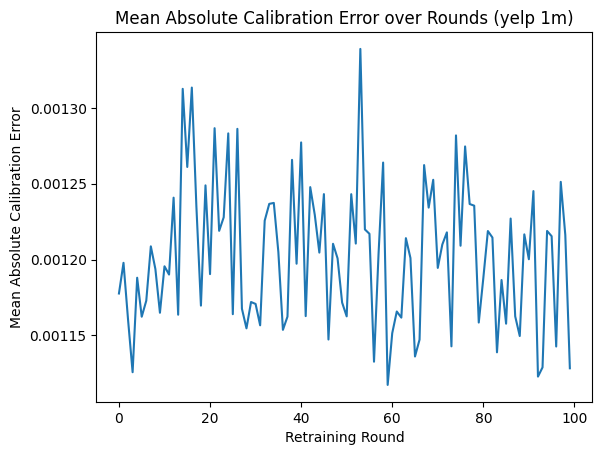

In [22]:
plt.plot(maces)
plt.title("Mean Absolute Calibration Error over Rounds (yelp 1m)")
plt.xlabel("Retraining Round")
plt.ylabel("Mean Absolute Calibration Error")

In [24]:
kl_divs

[2.067469581604004,
 2.103212856531143,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 2.015630360722542,
 nan,
 nan,
 nan,
 2.1894415658712387,
 nan,
 nan,
 2.100624396920204,
 2.2567337297201155,
 nan,
 nan,
 nan,
 nan,
 2.364538483262062,
 nan,
 2.2164950038194657,
 nan,
 nan,
 nan,
 nan,
 nan,
 2.3803760677576067,
 nan,
 nan,
 nan,
 2.259815586447716,
 nan,
 nan,
 nan,
 nan,
 nan]

Text(0, 0.5, 'Average KL Divergence')

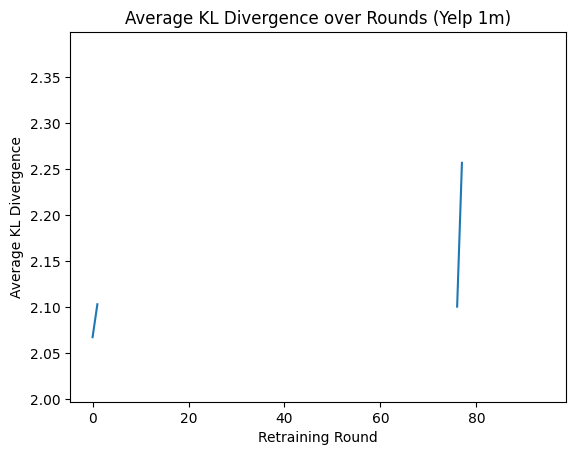

In [23]:
plt.plot(kl_divs)
plt.title("Average KL Divergence over Rounds (Yelp 1m)")
plt.xlabel("Retraining Round")
plt.ylabel("Average KL Divergence")

## Hipoteses:


1. O modelo está sendo treinado cada vez com mais dados. Talvez isso seja um problema? 
2. De fato, pode ser que o modelo recomende sempre algo muito similar ao que o usuário gosta no início. Dai entra o experimento do histórico do usuário mudar ao longo do tempo.
3. Sera se o MACE e kl div tao sendo justos? Tem usuario que não ta recebendo rec? TEm usuario que o historico não muda?
4. Pode ser que o retreino altere a divergencia KL e MACE. E se eu medir em toda rodada? Agora ta rapido de medir, isso não seria muito um problema.